In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore')

In [27]:
data = pd.read_csv('Lab 21 House_Rent_Dataset.csv')
data.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [28]:
data.tail()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent
4745,2022-05-04,2,15000,1000,4 out of 5,Carpet Area,Suchitra Circle,Hyderabad,Unfurnished,Bachelors,2,Contact Owner


In [29]:
data.sample(5)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
765,2022-06-27,1,7500,250,1 out of 7,Super Area,Chinmay Gaurang Infrastructure Old Panvel,Mumbai,Unfurnished,Bachelors/Family,1,Contact Owner
3239,2022-05-25,2,9000,600,2 out of 2,Carpet Area,"Valasaravakkam, Arcot Road",Chennai,Unfurnished,Bachelors/Family,2,Contact Owner
2687,2022-06-20,3,30000,1600,6 out of 10,Super Area,"Highland Tower, Dwarka Sector 12",Delhi,Unfurnished,Bachelors/Family,2,Contact Owner
1118,2022-05-23,1,24000,550,Ground out of 4,Carpet Area,Ghatkopar West,Mumbai,Unfurnished,Bachelors,1,Contact Agent
880,2022-05-31,2,15000,610,Ground out of 6,Carpet Area,"RNA Broadway Avenue, Mira Road",Mumbai,Semi-Furnished,Bachelors,1,Contact Owner


In [30]:
data.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')

In [31]:
data.shape

(4746, 12)

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [34]:
data.describe(include='object')

,Posted On,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Point of Contact
count,4746,4746,4746,4746,4746,4746,4746,4746
unique,81,480,3,2235,6,3,3,3
top,2022-07-06,1 out of 2,Super Area,Bandra West,Mumbai,Semi-Furnished,Bachelors/Family,Contact Owner
freq,311,379,2446,37,972,2251,3444,3216


In [35]:
data.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [40]:
duplicate_values = data.duplicated().sum()
duplicate_values

np.int64(260)

In [41]:
data = data.drop(['Posted On','Floor','Area Locality'],axis=1)
data

KeyError: "['Posted On', 'Floor', 'Area Locality'] not found in axis"

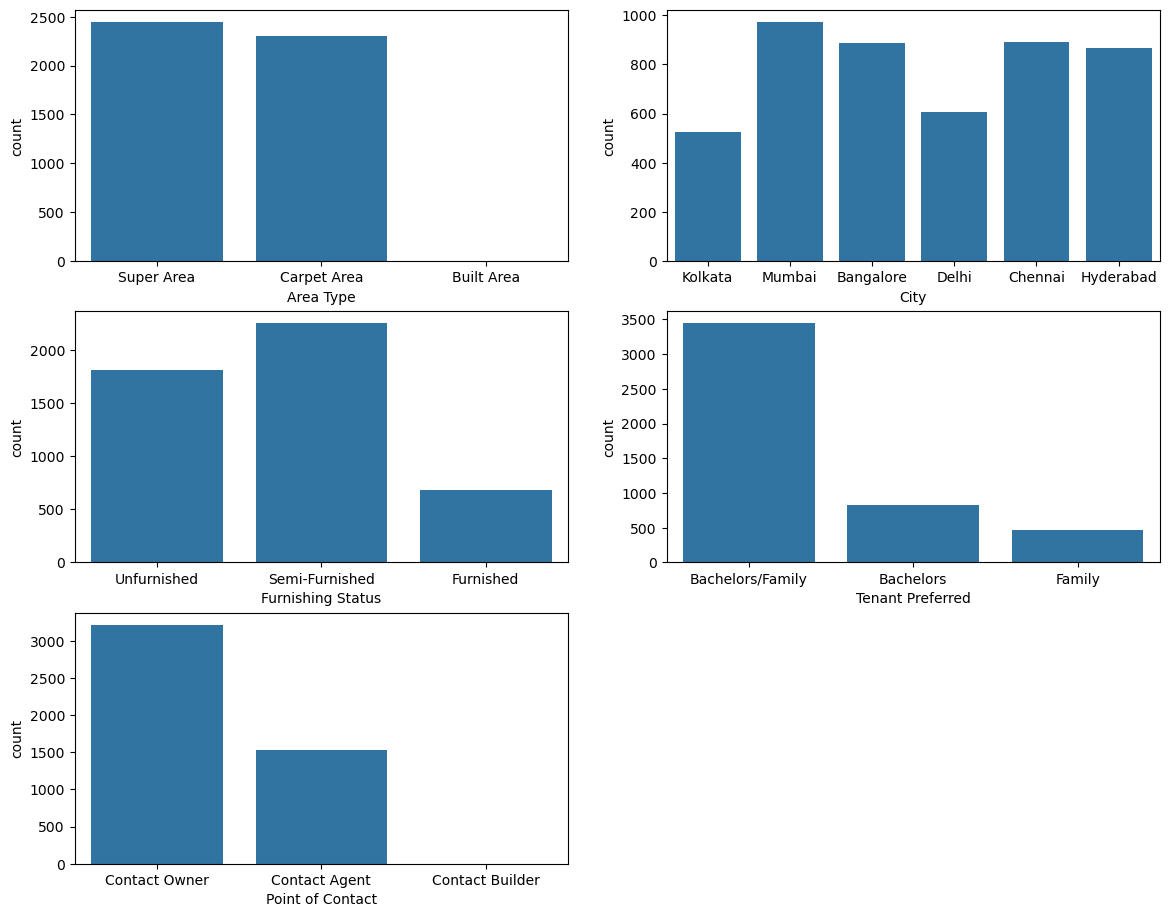

In [42]:
plt.figure(figsize=(14,15))
for i,col in enumerate(["Area Type","City","Furnishing Status","Tenant Preferred","Point of Contact"]):
    plt.subplot(4,2,i+1)
    sns.countplot(data=data,x=col)

Text(0.5, 1.0, 'Relation between rent nd BHK by city')

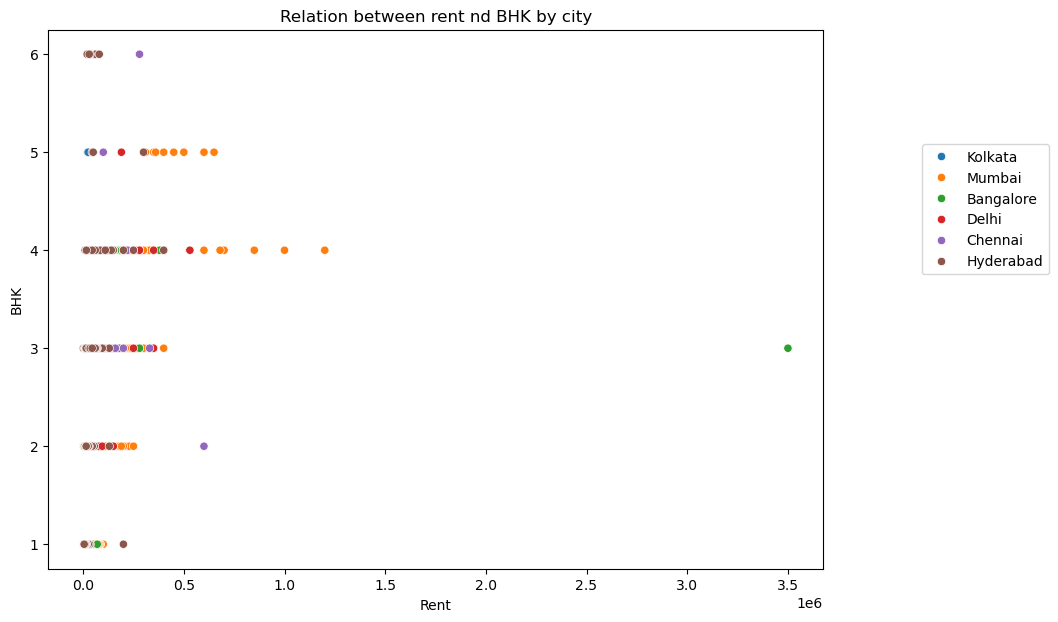

In [43]:
plt.figure(figsize=(10,7))
sns.scatterplot(x="Rent",y="BHK",data=data,hue="City")
plt.legend(bbox_to_anchor=(1.3,0.8))
plt.title("Relation between rent nd BHK by city")

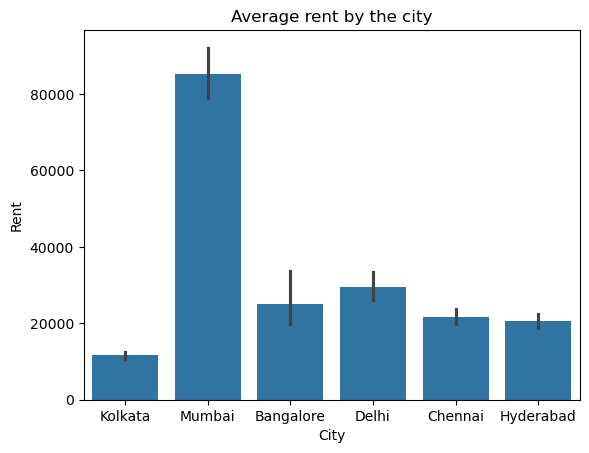

In [44]:
sns.barplot(data=data,x="City",y="Rent")
plt.title("Average rent by the city")
plt.show()

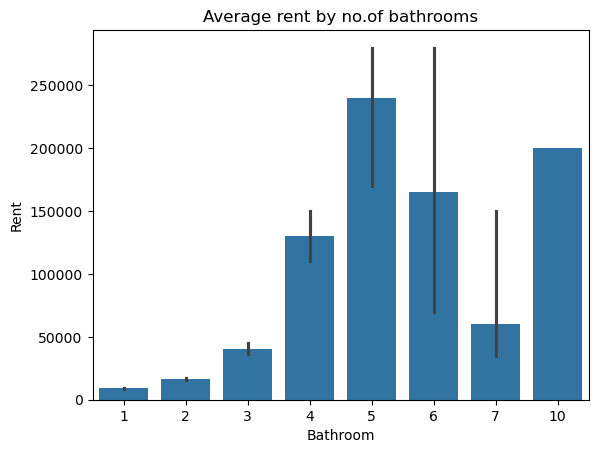

In [17]:
sns.barplot(data=data,x="Bathroom",y="Rent",estimator=np.median)
plt.title("Average rent by no.of bathrooms")
plt.show()

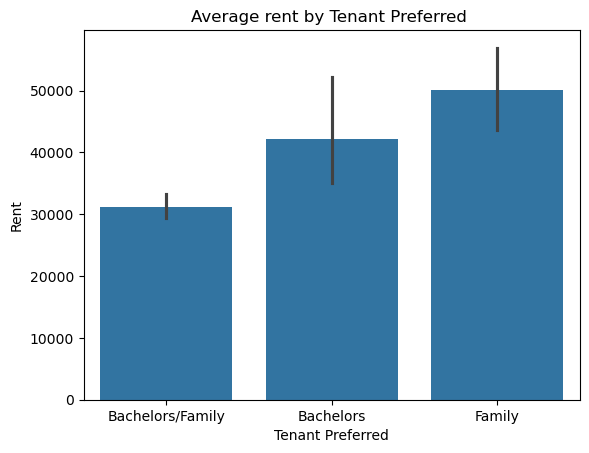

In [45]:
sns.barplot(data=data,x="Tenant Preferred",y="Rent")
plt.title("Average rent by Tenant Preferred ")
plt.show()

# Data preprocessing and splitting

In [47]:
pip install category-encoders

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score,GridSearchCV
from sklearn.svm import SVR
import sklearn.metrics as metrices
# import xgboost as xgb
# import category_encoders as ce
from sklearn.preprocessing import MinMaxScaler

In [49]:
def regression_results(y_true, y_pred):

    # Regression metrics
    explained_variance=metrics.explained_variance_score(y_true, y_pred)
    mean_absolute_error=metrics.mean_absolute_error(y_true, y_pred) 
    mse=metrics.mean_squared_error(y_true, y_pred) 
    #mean_squared_log_error=metrics.mean_squared_log_error(y_true, y_pred)
    median_absolute_error=metrics.median_absolute_error(y_true, y_pred)
    r2=metrics.r2_score(y_true, y_pred)

    print('explained_variance: ', round(explained_variance,4))    
    #print('mean_squared_log_error: ', round(mean_squared_log_error,4))
    print('r2: ', round(r2,4))
    print('MAE: ', round(mean_absolute_error,4))
    print('MSE: ', round(mse,4))
    print('RMSE: ', round(np.sqrt(mse),4))
    print('Median absolute error: ',round(median_absolute_error,4))

In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   BHK                4746 non-null   int64 
 1   Rent               4746 non-null   int64 
 2   Size               4746 non-null   int64 
 3   Area Type          4746 non-null   object
 4   City               4746 non-null   object
 5   Furnishing Status  4746 non-null   object
 6   Tenant Preferred   4746 non-null   object
 7   Bathroom           4746 non-null   int64 
 8   Point of Contact   4746 non-null   object
dtypes: int64(4), object(5)
memory usage: 333.8+ KB


In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [52]:
data.head()

,BHK,Rent,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,10000,1100,Super Area,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2,20000,800,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2,17000,1000,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2,10000,800,Super Area,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2,7500,850,Carpet Area,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [53]:
x = data.drop("Rent",axis=1)
y = data["Rent"]

In [54]:
x = pd.get_dummies(x,drop_first=True)


In [55]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=40)

In [56]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [57]:
y_pred = model.predict(x_test)
print(y_pred)

[-2.29255838e+04 -2.07032219e+04  3.26694897e+04  6.38532261e+03
  5.92427127e+03 -1.72864998e+04  7.09089333e+04  4.61201566e+04
  8.14346797e+04  3.36168538e+03 -2.58759314e+04  1.57265214e+04
 -1.38761038e+03  1.19780994e+05 -7.38515468e+03  9.33919170e+04
  6.81871556e+03  5.20767057e+04  1.42591191e+04  1.29067753e+03
 -9.62873630e+03  4.61645649e+04  7.78528894e+04  6.40567802e+04
  1.99584001e+03 -1.44927096e+04  5.24773903e+04  2.29216516e+04
  6.99757250e+04  7.04615591e+04  3.77551623e+04 -9.39550307e+03
  1.08037458e+05  6.18531272e+04  4.96003057e+04 -8.73080902e+03
  6.02793565e+04  2.94958179e+03  1.73480807e+05 -7.88802646e+03
  5.88249456e+04 -2.63613246e+04  2.17015397e+04  2.63611172e+04
 -1.71454924e+03  9.11382004e+04  1.61530241e+05 -1.49445360e+04
  1.43162626e+04  9.67482326e+03  1.12558569e+04  5.18316406e+04
 -6.27968598e+03 -1.03229812e+04  3.65729551e+04  3.90392888e+04
 -3.38801032e+04  9.25320714e+04  4.24280817e+04  3.46707273e+04
  3.12653289e+04  1.30350

In [58]:
print("R2_Score : ",round(r2_score(y_test,y_pred),4))
print("MAE : ",round(mean_absolute_error(y_test,y_pred),4))
print("MSE : ",round(mean_squared_error(y_test,y_pred),4))

R2_Score :  0.4408
MAE :  22204.8427
MSE :  1847054622.4325


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore')


In [64]:
d= pd.read_csv('Salary_Data.csv')
d.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [69]:
d.tail()

,YearsExperience,Salary
25,9.0,105582.0
26,9.5,116969.0
27,9.6,112635.0
28,10.3,122391.0
29,10.5,121872.0


In [70]:
d.columns

Index(['YearsExperience', 'Salary'], dtype='object')

In [71]:
d.shape

(30, 2)

In [75]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [78]:
d.describe()


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [79]:
d.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [80]:
duplicate_values = d.duplicated().sum()
duplicate_values

np.int64(0)

In [82]:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score,GridSearchCV
from sklearn.svm import SVR
import sklearn.metrics as metrices
# import xgboost as xgb
# import category_encoders as ce
from sklearn.preprocessing import MinMaxScaler